In [19]:
import xarray as xr
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr, wasserstein_distance
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import classification_report, jaccard_score, cohen_kappa_score, confusion_matrix
from scipy import stats
import seaborn as sns
import pandas as pd

from io import BytesIO
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

In [20]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2009-01-01"), pd.to_datetime("2025-12-31")
split_date = "2023-01-01"

sp = "HKP"
fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

peso = fishing_ds["PesoTotal"]/1000
peso = np.log1p(peso)
peso = peso.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = np.log1p(effort)
effort = effort.fillna(0)

fishing_class_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing_class = fishing_class_ds["CPUE_class"]
fishing_class = fishing_class.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

fishing, mask, peso, fishing_class, effort = xr.align(fishing, mask, peso, fishing_class, effort, join="inner")

#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)
fishing_cropped = croppedT(fishing)
mask_cropped = croppedT(mask)
peso_cropped = croppedT(peso)
fishing_class_cropped = croppedT(fishing_class)
effort_cropped = croppedT(effort)

print(fishing_cropped.shape)
print(mask_cropped.shape)
print(peso_cropped.shape)
print(fishing_class_cropped.shape)
print(effort_cropped.shape)

(204, 30, 17)
(204, 30, 17)
(204, 30, 17)
(204, 30, 17)
(204, 30, 17)


In [21]:
def compute_climatology_metrics_regression(y_true_da, y_pred_da, mask_da):
    # =====================================================
    # 1. EXTRACT ARRAYS & FLATTEN FOR METRICS
    # =====================================================
    # Extract underlying numpy arrays
    y_true = y_true_da.values
    y_pred = y_pred_da.values
    mask_spatial = mask_da.values > 0  # Ensure boolean
    
    # Broadcast 2D mask to 3D time series if necessary
    if mask_spatial.ndim == 2:
        mask_spatial = np.broadcast_to(mask_spatial, y_true.shape)

    # Flatten for global sklearn metrics
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_flat = mask_spatial.flatten()
    
    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # Clean NaNs strictly for valid indices (just in case they slipped through)
    valid = ~np.isnan(y_test_masked) & ~np.isnan(y_pred_masked)
    y_test_masked = y_test_masked[valid]
    y_pred_masked = y_pred_masked[valid]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat if data_range_flat > 0 else 0

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")

    # =====================================================
    # 3. GLOBAL HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    total_actual_hotspots = np.sum(actual_hotspots)
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)
    
    hit_rate_percent = shared_hotspots / total_actual_hotspots if total_actual_hotspots > 0 else 0
    
    print(f"\n--- Total Hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Hit Rate                       : {hit_rate_percent*100:.4f}%")
    

    # =====================================================
    # 4b. YEARLY HOTSPOT Hit Rate
    # =====================================================
    total_actual_hotspots_yearly_all = 0
    shared_hotspots_yearly_all = 0
    yearly_hit_rates = []
    
    # Iterate over the time dimension in steps of 12 (months)
    for year_idx in range(0, y_true.shape[0], 12):
        # Handle cases where the dataset might not be a perfect multiple of 12
        end_idx = min(year_idx + 12, y_true.shape[0])
        
        current_mask_year = mask_spatial[year_idx:end_idx]
        
        # Apply mask to the chunk of time steps
        y_true_year = y_true[year_idx:end_idx][current_mask_year]
        y_pred_year = y_pred[year_idx:end_idx][current_mask_year]
        
        # Clean NaNs
        valid_year = ~np.isnan(y_true_year) & ~np.isnan(y_pred_year)
        y_true_year = y_true_year[valid_year]
        y_pred_year = y_pred_year[valid_year]
        
        if len(y_true_year) == 0:
            continue
            
        # Calculate the threshold for the current year
        thresh_true_year = np.percentile(y_true_year, percentile)
        thresh_pred_year = np.percentile(y_pred_year, percentile)
        
        # Calculate overlap
        actual_hotspots_year = (y_true_year >= thresh_true_year)
        pred_hotspots_year = (y_pred_year >= thresh_pred_year)
        
        total_actual_year = np.sum(actual_hotspots_year)
        shared_year = np.sum(actual_hotspots_year & pred_hotspots_year)
        
        total_actual_hotspots_yearly_all += total_actual_year
        shared_hotspots_yearly_all += shared_year
        
        if total_actual_year > 0:
            yearly_hit_rates.append((shared_year / total_actual_year) * 100)

    mean_yearly_hit_rate = np.mean(yearly_hit_rates) if yearly_hit_rates else 0
    
    print(f"Mean Yearly Hit Rate                : {mean_yearly_hit_rate:.3f}%")

    
    # =====================================================
    # 4. MONTHLY HOTSPOT Hit Rate
    # =====================================================
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    for i in range(y_true.shape[0]):
        current_mask = mask_spatial[i]
        
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred[i][current_mask]
        
        valid_month = ~np.isnan(y_true_month) & ~np.isnan(y_pred_month)
        y_true_month = y_true_month[valid_month]
        y_pred_month = y_pred_month[valid_month]
        
        if len(y_true_month) == 0:
            continue
            
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    mean_monthly_hit_rate = np.mean(monthly_hit_rates) if monthly_hit_rates else 0
    
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")
    print(f"-------------------------------------------------\n")

# =====================================================
    # 5. SSIM (Structural Similarity) - SIMPLIFIED & ACCURATE
    # =====================================================
    # Replace NaNs with 0s globally for map functions (SSIM and Plotting)
    y_test_masked = np.nan_to_num(y_true, nan=0.0)
    y_pred_masked = np.nan_to_num(y_pred, nan=0.0)

    # Fix 1: Use a constant max range (1.0 for normalized floats, 255 for 8-bit integers)
    # Dynamic ranges cause inconsistent scoring between different test samples.
    data_range = 1.0 

    ssim_scores = []
    for i in range(y_true.shape[0]):
        # Fix 2: Switch to an 11x11 Gaussian window (the standard for realistic SSIM)
        _, ssim_map = ssim(
            y_test_masked[i],
            y_pred_masked[i],
            data_range=data_range,
            win_size=11,           # Standard window size
            gaussian_weights=True, # Mimics human visual system focus
            full=True
        )
        valid_ssim_pixels = ssim_map[mask_spatial[i]]
        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores) if ssim_scores else 0
    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # 6. PLOTTING
    # =====================================================
    # Mask out values visually using Numpy Masked Arrays
    y_true_m = ma.masked_where(~mask_spatial, y_test_masked)
    y_pred_m = ma.masked_where(~mask_spatial, y_pred_masked)

    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis') 
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_pred_plot2 = y_pred_m.mean(axis=(1, 2))
    y_true_plot2 = y_true_m.mean(axis=(1, 2))
    
    # Filter out NaNs if any time steps were entirely masked out
    valid_ts = ~np.isnan(y_true_plot2) & ~np.isnan(y_pred_plot2)
    r2_plot2 = r2_score(y_true_plot2[valid_ts], y_pred_plot2[valid_ts]) if np.any(valid_ts) else 0

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true_plot2, label="Real")
    ax.plot(y_pred_plot2, label="Predicho")
    ax.annotate(f"R2: {r2_plot2:.3f}",xy=(0.98, 0.02),xycoords="axes fraction",ha="right",va="bottom",)

    ax.set_xlabel("Tiempo (Meses)")
    ax.set_ylabel("Valor promedio")
    ax.legend()

    plt.show()
    
    metrics = [r2, pearson_corr, r2_plot2, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr, hit_rate_percent, mean_yearly_hit_rate, mean_monthly_hit_rate]
    columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
    metrics_df = pd.DataFrame(columns=columns)
    metrics_df.loc[len(metrics_df)] = metrics

    return metrics_df, fig

In [22]:
#regressions
fishing_train = fishing_cropped.sel(time=slice(None, split_date))
fishing_test = fishing_cropped.sel(time=slice(split_date, None))

peso_train = peso_cropped.sel(time=slice(None, split_date))
peso_test = peso_cropped.sel(time=slice(split_date, None))

effort_train = effort_cropped.sel(time=slice(None, split_date))
effort_test = effort_cropped.sel(time=slice(split_date, None))

mask_test = mask_cropped.sel(time=slice(split_date, None))




RMSE: 1.8750
Normalized RMSE: 0.1599 (15.99%)
MAE: 1.2660
R2: 0.4841
Pearson R: 0.7272
MBE: -0.5148
Wasserstein Distance: 0.9418
Spearman Rank Correlation: 0.70

--- Total Hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                       : 52.1111%
Mean Yearly Hit Rate                : 51.556%
Mean Monthly Hit Rate               : 38.511%
-------------------------------------------------

Mean Masked SSIM: 0.4848



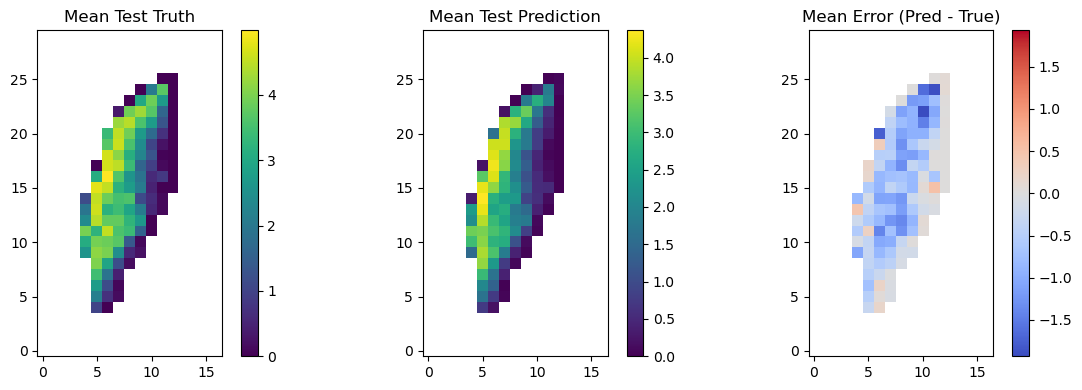

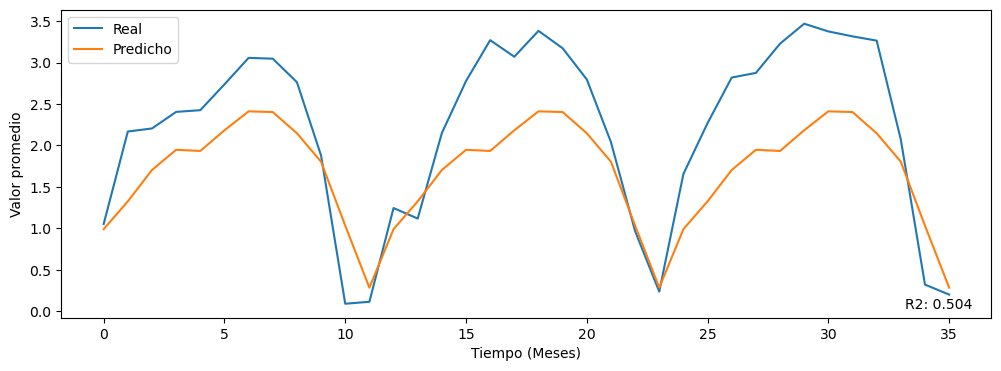

In [23]:

climatology = fishing_train.groupby("time.month").mean("time")
fishing_pred = climatology.sel(month=fishing_test.time.dt.month).drop_vars("month")
metrics_df, fig = compute_climatology_metrics_regression(fishing_test, fishing_pred, mask_test)

# save everyhtng to a excel workbook
ax = fig.axes[0]
ax.set_title("Serie temporal de climatología")
fig.canvas.draw()


img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"Climatology_{sp}"
with pd.ExcelWriter("./modelos/resultados/Regre/BL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/BL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")





In [24]:
fishing_class_train = fishing_class_cropped.sel(time=slice(None, split_date))
fishing_class_test = fishing_class_cropped.sel(time=slice(split_date, None))

# 2. Define a custom function to calculate the mode across a specific axis
def get_mode(x, axis):
    # scipy.stats.mode returns a tuple: (mode_array, counts_array)
    # We take index [0] to extract just the mode values.
    # keepdims=False ensures the dimensions align properly when xarray recombines them.
    return stats.mode(x, axis=axis, keepdims=False)[0]

# 3. Build the Climatology Model (Most frequent class per month from training set)
climatology_class = fishing_class_train.groupby("time.month").reduce(get_mode)

# 4. Predict on the Test Period
# Map the monthly mode back to the specific dates of the test set
fishing_class_pred = climatology_class.sel(month=fishing_class_test.time.dt.month).drop_vars("month")

In [25]:
def compute_climatology_metrics_classification(y_true_da, y_pred_da, mask_da):
    # =====================================================
    # 1. EXTRACT ARRAYS & FLATTEN FOR METRICS
    # =====================================================
    # Extract underlying numpy arrays
    y_true = y_true_da.values
    y_pred = y_pred_da.values
    mask_spatial = mask_da.values > 0  # Ensure boolean
    
    # Broadcast 2D mask to 3D time series if necessary
    if mask_spatial.ndim == 2:
        mask_spatial = np.broadcast_to(mask_spatial, y_true.shape)

    # Flatten for global sklearn metrics
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_flat = mask_spatial.flatten()
    
    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # Clean NaNs strictly for valid indices (just in case they slipped through)
    valid = ~np.isnan(y_test_masked) & ~np.isnan(y_pred_masked)
    y_test_masked = y_test_masked[valid]
    y_pred_masked = y_pred_masked[valid]

    # =====================================================
    # 2. Classification Metrics
    # =====================================================
    print("=== Classification Report ===")
    report = pd.DataFrame(classification_report(y_test_masked, y_pred_masked, labels=[0, 1, 2], output_dict=True)).T
    print(report)
    
    iou_per_class = jaccard_score(y_test_masked, y_pred_masked, average=None, labels=[0, 1, 2])
    kappa = cohen_kappa_score(y_test_masked, y_pred_masked)
    
    print("=== Spatial Segmentation Metrics ===")
    print(f"IoU Class 1 (Low CPUE):      {iou_per_class[1]:.3f}")
    print(f"IoU Class 2 (High CPUE):     {iou_per_class[2]:.3f}")
    print(f"Cohen's Kappa Score:         {kappa:.3f}\n")
    
    # New Plot: Confusion Matrix
    class_labels = ['None (0)', 'Low CPUE (1)', 'High CPUE (2)']
    cm = pd.DataFrame(confusion_matrix(y_test_masked,y_pred_masked,labels=[0, 1, 2]),index=class_labels,columns=class_labels)

    # =====================================================
    # 5. SSIM (Structural Similarity)
    # =====================================================
    # Replace NaNs with 0s globally for map functions (SSIM and Plotting)
    y_true_clean = np.nan_to_num(y_true, nan=0.0)
    y_pred_clean = np.nan_to_num(y_pred, nan=0.0)
    
    masked_data = y_true_clean[mask_spatial]
    data_range = masked_data.max() - masked_data.min() if len(masked_data) > 0 else 1.0

    ssim_scores = []
    for i in range(y_true.shape[0]):
        _, ssim_map = ssim(
            y_true_clean[i],
            y_pred_clean[i],
            data_range=data_range,
            win_size=5,
            full=True
        )
        valid_ssim_pixels = ssim_map[mask_spatial[i]]
        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores) if ssim_scores else 0
    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # 6. PLOTTING
    # =====================================================
    # Mask out values visually using Numpy Masked Arrays
    y_true_m = ma.masked_where(~mask_spatial, y_true_clean)
    y_pred_m = ma.masked_where(~mask_spatial, y_pred_clean)

    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis') 
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_pred_plot2 = y_pred_m.sum(axis=(1, 2))
    y_true_plot2 = y_true_m.sum(axis=(1, 2))
    
    # Filter out NaNs if any time steps were entirely masked out
    valid_ts = ~np.isnan(y_true_plot2) & ~np.isnan(y_pred_plot2)
    r2_plot2 = r2_score(y_true_plot2[valid_ts], y_pred_plot2[valid_ts]) if np.any(valid_ts) else 0

    return report, iou_per_class, kappa, cm, y_true_plot2, y_pred_plot2, r2_plot2

=== Classification Report ===
              precision    recall  f1-score      support
0              0.744201  0.933068  0.828001  2510.000000
1              0.569620  0.271357  0.367597   995.000000
2              0.634812  0.560804  0.595518   995.000000
accuracy       0.704444  0.704444  0.704444     0.704444
macro avg      0.649544  0.588410  0.597038  4500.000000
weighted avg   0.681412  0.704444  0.674796  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.225
IoU Class 2 (High CPUE):     0.424
Cohen's Kappa Score:         0.456

Mean Masked SSIM: 0.3883



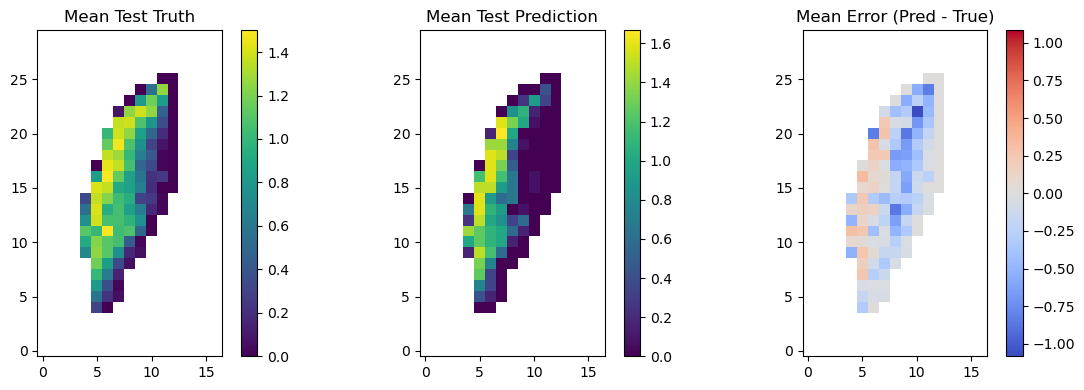

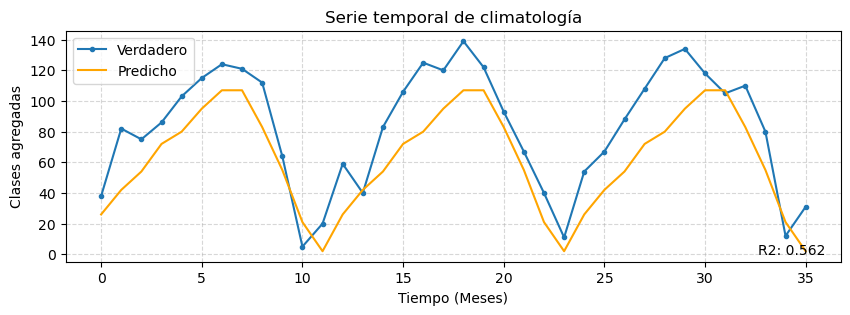

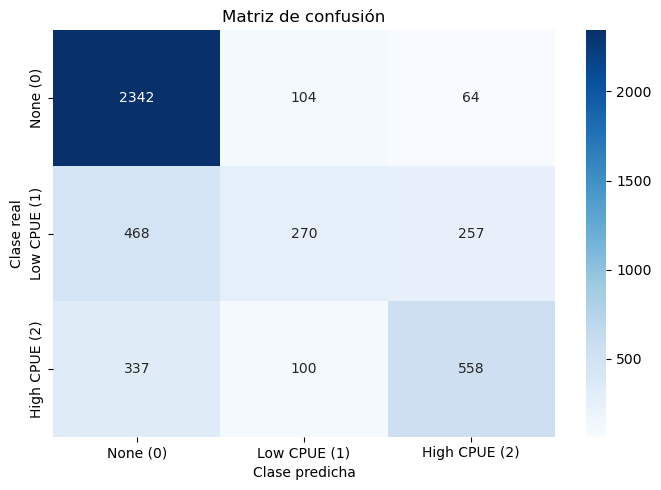

In [26]:
report, iou_per_class, kappa, cm, y_true_plot, y_pred_plot, r2_plot = compute_climatology_metrics_classification(fishing_class_test, fishing_class_pred, mask_test)

iou_per_class = pd.DataFrame(iou_per_class, index=["Class 0", "Class 1", "Class 2"], columns=["IoU"])

metrics_df = pd.DataFrame({
    "Cohen's Kappa": [kappa],
    "Aggregated R2": [r2_plot],
})


plt.figure(figsize=(10, 3))
plt.plot(y_true_plot, label="Verdadero", marker='o', markersize=3)
plt.plot(y_pred_plot, color="orange", label="Predicho")
plt.annotate(f"R2: {r2_plot:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
plt.xlabel("Tiempo (Meses)")
plt.ylabel("Clases agregadas")
plt.title(f"Serie temporal de climatología")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
img_buffer2 = BytesIO()
plt.savefig(img_buffer2, format="png", bbox_inches="tight")
img_buffer2.seek(0)
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión")
plt.tight_layout()
img_buffer3 = BytesIO()
plt.savefig(img_buffer3, format="png", bbox_inches="tight")
img_buffer3.seek(0)

# save everyhtng to a excel workbook
with pd.ExcelWriter("./modelos/resultados/Class/BL_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    sheet_name = f"Climatology_{sp}"
    report.to_excel(writer, sheet_name=sheet_name, startrow=1)

with pd.ExcelWriter("./modelos/resultados/Class/BL_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    sheet_name = f"Climatology_{sp}"
    iou_per_class.to_excel(writer, sheet_name=sheet_name, startrow=len(report) + 3)
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=len(report) + len(iou_per_class) + 6, index=False)
    ws = writer.sheets[sheet_name]
    img2 = Image(img_buffer2)
    ws.add_image(img2, f"N1")
    img3 = Image(img_buffer3)
    ws.add_image(img3, f"N21")



In [27]:
print("y_true shape:", fishing_class_test.shape)
print("y_pred shape:", fishing_class_pred.shape)
print("mask shape:", mask_test.shape)

y_true shape: (36, 30, 17)
y_pred shape: (36, 30, 17)
mask shape: (36, 30, 17)
